In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve, auc
import joblib
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif

In [45]:

#import the train and test csv
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

print("NA values for Traininig set - ",train_df.isna().sum())
print("NA values for Testing set - ",test_df.isna().sum())
#no imputation needed since all values are filled.

NA values for Traininig set -  label    0
f0       0
f1       0
f2       0
f3       0
f4       0
f5       0
f6       0
f7       0
f8       0
f9       0
f10      0
f11      0
f12      0
f13      0
f14      0
f15      0
f16      0
f17      0
f18      0
f19      0
f20      0
f21      0
f22      0
f23      0
f24      0
f25      0
f26      0
f27      0
dtype: int64
NA values for Testing set -  f0     0
f1     0
f2     0
f3     0
f4     0
f5     0
f6     0
f7     0
f8     0
f9     0
f10    0
f11    0
f12    0
f13    0
f14    0
f15    0
f16    0
f17    0
f18    0
f19    0
f20    0
f21    0
f22    0
f23    0
f24    0
f25    0
f26    0
f27    0
dtype: int64


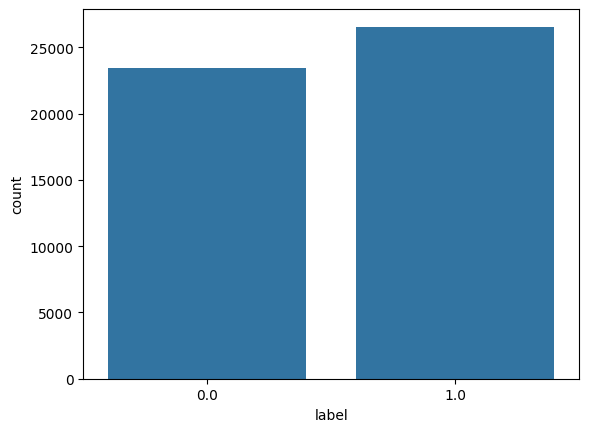

In [46]:
#eda
sns.countplot(data = train_df, x= 'label')
plt.show()

In [47]:
X = train_df.drop('label', axis=1)  
y = train_df['label']
print(X.head())
print(y.head())

         f0        f1        f2        f3        f4        f5        f6  \
0  0.869293 -0.635082  0.225690  0.327470 -0.689993  0.754202 -0.248573   
1  0.907542  0.329147  0.359412  1.497970 -0.313010  1.095531 -0.557525   
2  0.798835  1.470639 -1.635975  0.453773  0.425629  1.104875  1.282322   
3  1.344385 -0.876626  0.935913  1.992050  0.882454  1.786066 -1.646778   
4  1.105009  0.321356  1.522401  0.882808 -1.205349  0.681466 -1.070464   

         f7        f8        f9  ...       f18       f19       f20       f21  \
0 -1.092064  0.000000  1.374992  ... -0.010455 -0.045767  3.101961  1.353760   
1 -1.588230  2.173076  0.812581  ... -1.138930 -0.000819  0.000000  0.302220   
2  1.381664  0.000000  0.851737  ...  1.128848  0.900461  0.000000  0.909753   
3 -0.942383  0.000000  2.423265  ... -0.678379 -1.360356  0.000000  0.946652   
4 -0.921871  0.000000  0.800872  ... -0.373566  0.113041  0.000000  0.755856   

        f22       f23       f24       f25       f26       f27  
0  0

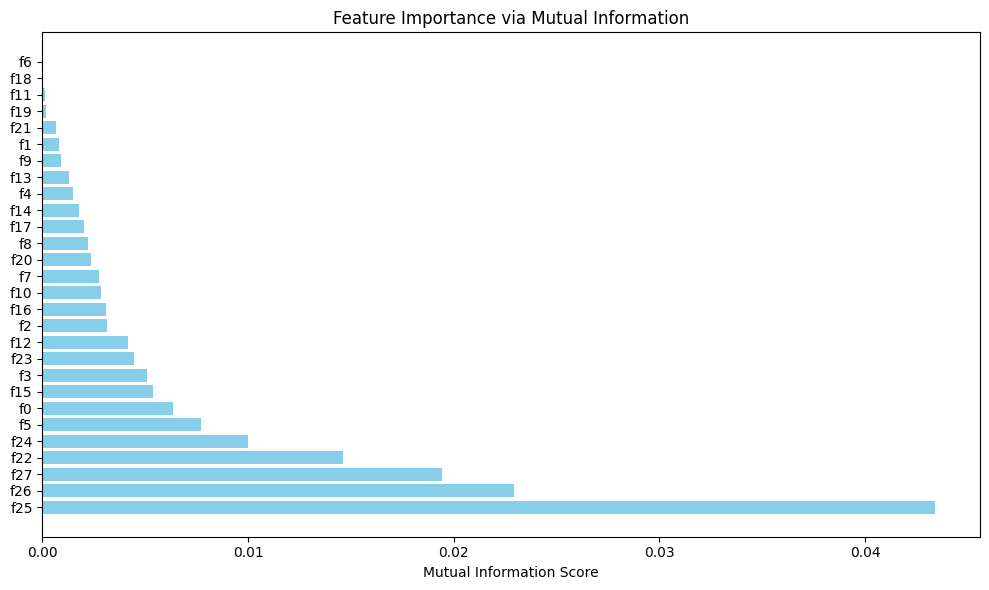

In [ ]:

#mutual info computation
mi_scores = mutual_info_classif(X, y, discrete_features='auto', random_state=42)

#plotting mutual info graph
mi_df = pd.DataFrame({'Feature': X.columns, 'MI Score': mi_scores})
mi_df = mi_df.sort_values(by='MI Score', ascending=False)
plt.figure(figsize=(10, 6))
plt.barh(mi_df['Feature'], mi_df['MI Score'], color='skyblue')
plt.xlabel("Mutual Information Score")
plt.title("Feature Importance via Mutual Information")
plt.tight_layout()
plt.show()

In [49]:
#removing features that are below the min threshold for mutual info
mi_series = pd.Series(mi_scores, index=X.columns)
MI_THRESHOLD = 0.002
selected_features = mi_series[mi_series > MI_THRESHOLD].index
print(f"Selected {len(selected_features)} features out of {X.shape[1]}")
X = X[selected_features]
test_df = test_df[selected_features]
print('\n Dataset After removal - ')
print(X)

Selected 18 features out of 28

 Dataset After removal - 
             f0        f2        f3        f5        f7        f8       f10  \
0      0.869293  0.225690  0.327470  0.754202 -1.092064  0.000000 -0.653674   
1      0.907542  0.359412  1.497970  1.095531 -1.588230  2.173076 -0.213642   
2      0.798835 -1.635975  0.453773  1.104875  1.381664  0.000000  1.540659   
3      1.344385  0.935913  1.992050  1.786066 -0.942383  0.000000 -0.676016   
4      1.105009  1.522401  0.882808  0.681466 -0.921871  0.000000  1.020974   
...         ...       ...       ...       ...       ...       ...       ...   
49995  0.620218  0.157442  1.442791  2.327923 -0.072010  0.000000  1.237590   
49996  0.686833 -1.417914  1.311205  0.517214 -1.190188  0.000000 -0.632304   
49997  0.728559 -1.397939  0.344134  0.951158 -1.400851  0.000000 -0.540023   
49998  1.477981 -1.546087  0.835522  0.785623  0.079991  2.173076 -1.805723   
49999  1.769149 -1.643743  0.601503  0.670656 -0.580930  0.000000  0.2739

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
pipelines = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000))
    ]),

    "Random Forest": Pipeline([
        ("scaler", StandardScaler()),
        ("model", RandomForestClassifier(random_state=42))
    ]),

    "Gradient Boosting": Pipeline([
        ("scaler", StandardScaler()),
        ("model", GradientBoostingClassifier(random_state=42))
    ])
}

param_grids = {
    "Logistic Regression": {
        "model__C": [0.1, 1, 10],
        "model__class_weight": ["balanced"]
    },

    "Random Forest": {
        "model__n_estimators": [200, 300],
        "model__max_depth": [5, 10, 15],
        "model__min_samples_split": [5, 10],
        "model__class_weight": ["balanced"]
    },

    "Gradient Boosting": {
        "model__n_estimators": [200, 300],
        "model__learning_rate": [0.05, 0.1],
        "model__max_depth": [3, 5, 10],
        "model__subsample": [0.8, 1.0]
    }
}
#grid search for best parameters
best_models = {}
results = {}
for name in pipelines:
    print(f"\nRunning Grid Search for {name}...")

    grid = GridSearchCV(
        pipelines[name],
        param_grids[name],
        scoring="roc_auc",
        cv=3,
        n_jobs=-1
    )
    grid.fit(X_train, y_train)
    best_models[name] = grid.best_estimator_
    y_pred = grid.predict(X_val)
    y_prob = grid.predict_proba(X_val)[:, 1]
    #evaluation metrics
    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    roc = roc_auc_score(y_val, y_prob)
    results[name] = roc
    print(f"Best Params: {grid.best_params_}")
    print(f"Accuracy  : {acc:.4f}")
    print(f"F1 Score  : {f1:.4f}")
    print(f"ROC-AUC   : {roc:.4f}")

model_names = list(results.keys())
roc_scores = list(results.values())
plt.figure(figsize=(8, 5))
plt.bar(model_names, roc_scores)
plt.xlabel("Models")
plt.ylabel("ROC-AUC Score")
plt.title("Model Comparison Based on ROC-AUC")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()



Running Grid Search for Logistic Regression...
Best Params: {'model__C': 10, 'model__class_weight': 'balanced'}
Accuracy  : 0.6376
F1 Score  : 0.6628
ROC-AUC   : 0.6785

Running Grid Search for Random Forest...
Best Params: {'model__class_weight': 'balanced', 'model__max_depth': 15, 'model__min_samples_split': 10, 'model__n_estimators': 300}
Accuracy  : 0.7089
F1 Score  : 0.7245
ROC-AUC   : 0.7845

Running Grid Search for Gradient Boosting...
Best Params: {'model__learning_rate': 0.05, 'model__max_depth': 5, 'model__n_estimators': 200, 'model__subsample': 0.8}
Accuracy  : 0.7137
F1 Score  : 0.7339
ROC-AUC   : 0.7896

Best Model Selected: Gradient Boosting


Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 GradientBoostingClassifier(learning_rate=0.05, max_depth=5,
                                            n_estimators=200, random_state=42,
                                            subsample=0.8))])

In [ ]:

#best model selection
best_model_name = max(results, key=results.get)
best_model = best_models[best_model_name]

print("\n===============================")
print(f"Best Model Selected: {best_model_name}")
print("===============================")
#train best model on given data
best_model.fit(X, y)

In [ ]:
sample_sub = pd.read_csv("sample_submission.csv")
test_predictions = best_model.predict(test_df)
submission = sample_sub.copy()
submission.iloc[:, 1] = test_predictions  # overwrite prediction column
submission.to_csv("subCSV.csv", index=False)
print("subCSV.csv generated correctly using sample submission format.")

subCSV.csv generated correctly using sample submission format.


In [ ]:
joblib.dump(best_model, "best_model.pkl")
joblib.dump(list(selected_features), "selected_features.pkl")

print("Deployment artifacts saved:")
print("- best_model.pkl")
print("- selected_features.pkl")

Deployment artifacts saved:
- best_model.pkl
- selected_features.pkl


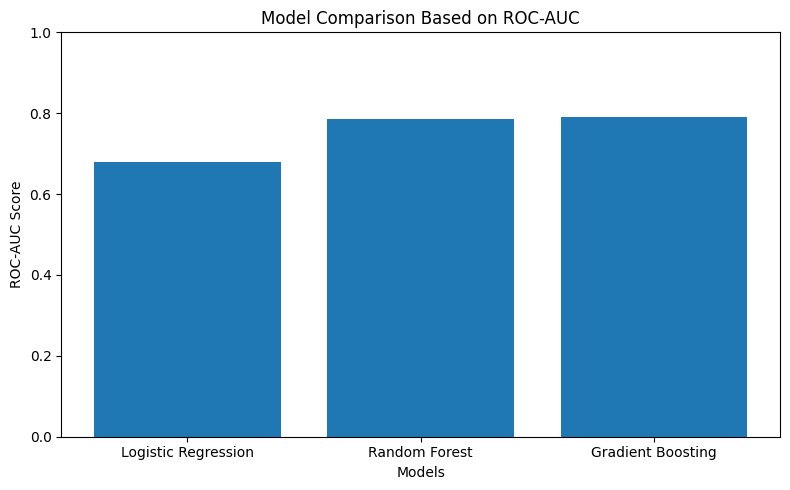

In [59]:
# ===============================
# Model Comparison Plot
# ===============================

model_names = list(results.keys())
roc_scores = list(results.values())

plt.figure(figsize=(8, 5))
plt.bar(model_names, roc_scores)
plt.xlabel("Models")
plt.ylabel("ROC-AUC Score")
plt.title("Model Comparison Based on ROC-AUC")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


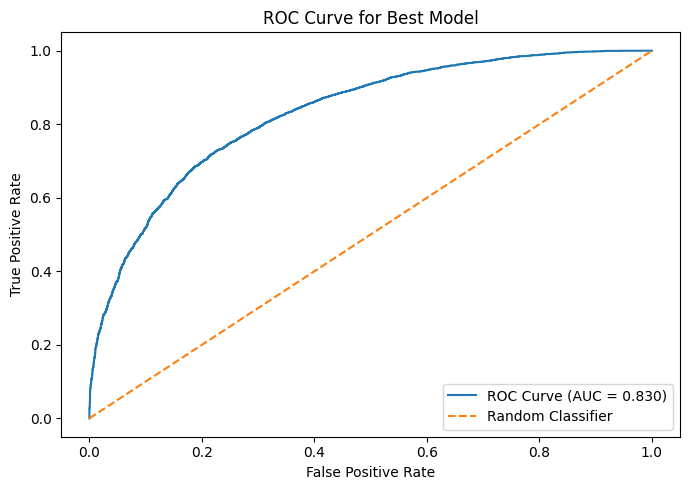

In [62]:
y_prob_best = best_model.predict_proba(X_val)[:, 1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_val, y_prob_best)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Best Model")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()